In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import accuracy_score
from scipy.stats import chi2_contingency

# USA Experiments


In [15]:


def calcular_porcentajes_anes(lista, exp):
    if exp == 3:
      total = len(lista)
      if total == 0:
          return [0, 0, 0, 0]

      counts = lista.value_counts()

      # Obtener los conteos específicos para 1, 2 y 3, y manejar el caso donde un valor no está presente
      count_1 = counts.get(1, 0)
      count_2 = counts.get(2, 0)
      count_3 = counts.get(3, 0)
      count_4 = counts.get(-1, 0)

      porcentaje_1 = (count_1 / total) * 100
      porcentaje_2 = (count_2 / total) * 100
      porcentaje_3 = (count_3 / total) * 100
      porcentaje_4 = (count_4 / total) * 100

      return [porcentaje_1, porcentaje_2, porcentaje_3, porcentaje_4]
    else:
      total = len(lista)
      if total == 0:
          return [0, 0, 0, 0, 0]

      counts = lista.value_counts()

      # Obtener los conteos específicos para 1, 2 y 3, y manejar el caso donde un valor no está presente
      count_1 = counts.get(1, 0)
      count_2 = counts.get(2, 0)
      count_3 = counts.get(3, 0)
      count_4 = counts.get(4, 0)
      count_5 = counts.get(-1, 0)

      porcentaje_1 = (count_1 / total) * 100
      porcentaje_2 = (count_2 / total) * 100
      porcentaje_3 = (count_3 / total) * 100
      porcentaje_4 = (count_4 / total) * 100
      porcentaje_5 = (count_5 / total) * 100

      return [porcentaje_1, porcentaje_2, porcentaje_3, porcentaje_4, porcentaje_5]



def jsd_function_anes(original, pred, exp):
    # Distribuciones de votos reales y predichos
    P = calcular_porcentajes_anes(original, exp)
    Q = calcular_porcentajes_anes(pred, exp)
    # Cálculo de Jensen-Shannon Divergence
    jsd = jensenshannon(P, Q, base=2)
    return jsd



def media_armonica(jsd, acc):
  inverted_jsd = 1- jsd
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
  return h



In [16]:
#metrics_group: dataframe str str int -> list(float)
#Calcula la correlación y la precisión apra un grupo específico del dataframe y los devuelve en un arreglo
def metrics_group_anes(df, group, id, pred_variable, pred_column_name, exp,
                       return_metrics_array=True,
                       n_bootstrap=1000, confidence_level=0.95, random_seed=None):
  props_array = []
  if group == "zona_u_r":
    if id == "city":
      group_index = (df[group] == 1) | (df[group] == 2)
    if id == "rural":
      group_index = (df[group] == 3) | (df[group] == 4)

  elif group == "edad":
    if id == "joven":
      group_index =  (df["edad"] >= 18) & (df["edad"] <= 26)
    elif id == "adulto":
      group_index = (df["edad"] >= 27) & (df["edad"] <= 59)
    elif id == "mayor":
      group_index = (df["edad"] >= 60)

  elif group == "race":
    if id == "blanco":
      group_index = (df[group] == 1)
    elif id == "otra raza":
      group_index = (df[group] == 2) | (df[group] == 3) | (df[group] == 4) | (df[group] == 5) | (df[group] == 6)
    elif id == "no responde":
      group_index = (df[group] == 9) | (df[group] == 8) | (df[group] == -9) | (df[group] == -8) | (df[group] == 99) | (df[group] == 88)

  elif group == "gse":
    if id == "high class":
      group_index = (df["gse"] == 20) | (df["gse"] == 21) | (df["gse"] == 22)
    elif id == "middle class":
      group_index = (df["gse"] == 10) | (df["gse"] == 11) | (df["gse"] == 12) | (df["gse"] == 13) | (df["gse"] == 14) | (df["gse"] == 15) | (df["gse"] == 16) | (df["gse"] == 17) | (df["gse"] == 18) | (df["gse"] == 19)
    elif id == "poor":
      group_index = (df["gse"] == 1) | (df["gse"] == 2) | (df["gse"] == 3) | (df["gse"] == 4) | (df["gse"] == 5) | (df["gse"] == 6) | (df["gse"] == 7) | (df["gse"] == 8) | (df["gse"] == 9)
    elif id == "no sabe":
      group_index = (df[group] == 88) | (df[group] == 99)|(df[group] == -8) | (df[group] == -9)

  elif group == "iden_pol_2":
    if id == "izq":
      group_index = (df[group] == 1) | (df[group] == 2) | (df[group] == 3)
    elif id == "center":
      group_index = (df[group] == 4)
    elif id == "der":
      group_index = (df[group] == 5) | (df[group] == 6) | (df[group] == 7)
    elif id == "ninguno":
      #print("derecha")
      group_index = (df[group] == 88) | (df[group] == 99) | (df[group] == -9) | (df[group] == -8)

  elif group == "esc_nivel_1":
    if id == "low education":
      group_index = (df[group] == 1) | (df[group] ==2)
    elif id == "medium education": #highschool, college incompleto
      group_index = (df[group] ==2) | (df[group] == 3) | (df[group] == 4) | (df[group] == 5)
    elif id == "high education": # bachelor y mayor a master
      group_index = (df[group] == 6) | (df[group] == 7) | (df[group] == 8)
    elif id == "otro":
      group_index = (df[group] == 95) | (df[group] == -8)| (df[group] == -9) | (df[group] == 88)| (df[group] == 99)

  elif group == "religion_82":
    if id == "religioso":
      group_index = (df[group] == 1) | (df[group] == 2) | (df[group] == 3) | (df[group] == 4) | (df[group] == 5) | (df[group] == 6) | (df[group] == 7)| (df[group] == 8)
    if id == "ateo/agnostico":
      group_index = (df[group] == 9) | (df[group] == 10) | (df[group] == 11) | (df[group] == 12)
    if id == "no sabe":
      group_index = (df[group] == 88) | (df[group] == 99)|(df[group] == -8) | (df[group] == -9)

  elif group == "iden_pol_3":
    if id == "democrata":
      group_index = (df[group] == 1) | (df[group] == 2)
    if id == "republican":
      group_index = (df[group] == 6) | (df[group] ==7 )
    if id == "otro":
      group_index = (df[group] == 3) | (df[group] == 4) | (df[group] == 5) | (df[group] == 88) | (df[group] == 99)| (df[group] == -8) | (df[group] == -9)

  else:
    group_index = df[group]==id

  df_group = df[group_index]

  #print(df_group)

  if return_metrics_array:
    if len(df_group) == 0: #Si no hay datos de este grupo
      if n_bootstrap > 0:
        return [None]*13
      return [None,None, None, None, None]

    jsd = jsd_function_anes(df_group[pred_variable],df_group[pred_column_name], exp)
    acc = accuracy_score(df_group[pred_variable], df_group[pred_column_name])
    h = media_armonica(jsd,acc)

    if n_bootstrap > 0:
      rng = np.random.default_rng(random_seed)
      boot_metrics = np.empty((n_bootstrap, 4))  # jsd, acc, h, jss
      n_samples = len(df_group)
      for i in range(n_bootstrap):
        sample = df_group.sample(n=n_samples, replace=True,
                                 random_state=int(rng.integers(0, 2**31)))
        b_jsd = jsd_function_anes(sample[pred_variable], sample[pred_column_name], exp)
        b_acc = accuracy_score(sample[pred_variable], sample[pred_column_name])
        b_h = media_armonica(b_jsd, b_acc)
        b_jss = 1 - b_jsd
        boot_metrics[i] = [b_jsd, b_acc, b_h, b_jss]
      alpha = 1 - confidence_level
      lo = np.nanpercentile(boot_metrics, 100 * alpha / 2, axis=0)
      hi = np.nanpercentile(boot_metrics, 100 * (1 - alpha / 2), axis=0)
      # Return order matches non-bootstrap: [jsd, jsd_general, acc, h, jss, CIs...]
      return [jsd, jsd * len(df_group) / 660, acc, h, 1-jsd,
              lo[0], hi[0], lo[1], hi[1], lo[2], hi[2], lo[3], hi[3]]

    props_array.append(jsd) #correlation
    props_array.append(jsd*len(df_group)/660) #correlation
    props_array.append(acc) #correlation
    props_array.append(h) #media armónica
    props_array.append(1-jsd) #media armónica
    #print(props_array)
    return props_array
  else:
    return group_index

In [17]:
def wjsd_calculator_anes(df):
  group_index = (df["Group"] == "Woman") | (df["Group"] == "Man")
  df_gender = df[group_index]

  group_index = (df["Group"] == "Young adult") | (df["Group"] == "Adult") | (df["Group"] == "Senior adult")
  df_age = df[group_index]

  group_index = (df["Group"] == "City/Suburb") | (df["Group"] == "Small town/Rural")
  df_region = df[group_index]

  group_index = (df["Group"] == "White") | (df["Group"] == "Other race") | \
   (df["Group"] == "None (indigenous)")
  df_originario = df[group_index]

  group_index = (df["Group"] == "Low education") | (df["Group"] == "Medium education") \
  | (df["Group"] == "High education") | (df["Group"] == "None (education)")
  df_escolaridad = df[group_index]

  group_index = (df["Group"] == "Left") | (df["Group"] == "Center") | (df["Group"] == "Right") \
  | (df["Group"] == "No ideology")
  df_ideology = df[group_index]
  #print(df_ideology)

  group_index = (df["Group"] == "Democrat") | (df["Group"] == "Republican") | (df["Group"] == "None party")
  df_party = df[group_index]
  #print(df_ideology)

  group_index = (df["Group"] == "High class") | (df["Group"] == "Middle class") | (df["Group"] == "Low class") | (df["Group"] == "No class")
  df_gse = df[group_index]

  group_index = (df["Group"] == "Religious") | (df["Group"] == "Atheist/agnostic") | \
   (df["Group"] == "No religion response")
  df_religion = df[group_index]

  weighted_mean_jsd = (df_gender[["JSD"]].sum()+ df_age[["JSD"]].sum()+ df_party[["JSD"]].sum()+ df_escolaridad[["JSD"]].sum() + df_originario[["JSD"]].sum() + df_region[["JSD"]].sum() + df_ideology[["JSD"]].sum() + df_gse[["JSD"]].sum() + df_religion[["JSD"]].sum())/9
  return weighted_mean_jsd["JSD"]

In [18]:
#metrics_dataset_gen: dataframe -> dataframe
#GENERA LA TABLA CON LAS CORRELACIONES  Y PRECISIONES PARA CADA SUBGRUPO DE INTERÉS.
def metrics_dataset_gen_anes(df, pred_variable,  exp, pred_column_name= "pred", eng = False,
                             n_bootstrap=1000, confidence_level=0.95, random_seed=None):

  names = ["Woman", "Man", "Young adult", "Adult", "Senior adult", "City/Suburb", \
         "Small town/Rural", "White", "Non-White", \
         "Low education", "Medium education", "High education",  \
         "Low class", "Middle class", "High class", "Left", "Center", "Right", "No ideology", \
         "Democrat", "Republican", "None party","Religious", "Atheist/agnostic", "No religion response", "Total"]

  base_columns = ["Group", "JSD general", "JSD", "Accuracy", "Media armónica", "JSS"]
  ci_columns = ["JSD_CI_lower", "JSD_CI_upper", "Accuracy_CI_lower", "Accuracy_CI_upper",
                "Media armónica_CI_lower", "Media armónica_CI_upper", "JSS_CI_lower", "JSS_CI_upper"]

  if n_bootstrap > 0:
    columns = base_columns + ci_columns
  else:
    columns = base_columns

  metrics_df = pd.DataFrame(columns=columns)

  bootstrap_kwargs = dict(n_bootstrap=n_bootstrap, confidence_level=confidence_level, random_seed=random_seed)

  metrics_df.loc[0] = [names[0]] + metrics_group_anes(df, "sexo", 2,pred_variable, pred_column_name,  exp, **bootstrap_kwargs)
  metrics_df.loc[1] = [names[1]] + metrics_group_anes(df, "sexo", 1, pred_variable, pred_column_name,  exp, **bootstrap_kwargs)

  metrics_df.loc[2] = [names[2]] + metrics_group_anes(df, "edad", "joven",pred_variable, pred_column_name,  exp, **bootstrap_kwargs)
  metrics_df.loc[3] = [names[3]] + metrics_group_anes(df, "edad", "adulto", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)
  metrics_df.loc[4] = [names[4]] + metrics_group_anes(df, "edad", "mayor", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)

  metrics_df.loc[5] = [names[5]] + metrics_group_anes(df, "zona_u_r", "city", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)
  metrics_df.loc[6] = [names[6]] + metrics_group_anes(df, "zona_u_r", "rural", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)

  metrics_df.loc[7] = [names[7]] + metrics_group_anes(df, "race", "blanco", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)
  metrics_df.loc[8] = [names[8]] + metrics_group_anes(df, "race", "otra raza", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)
  # metrics_df.loc[9] = [names[9]] + metrics_group_anes(df, "race", "no responde", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)

  metrics_df.loc[9] = [names[9]] + metrics_group_anes(df, "esc_nivel_1", "low education", pred_variable, pred_column_name, exp, **bootstrap_kwargs)
  metrics_df.loc[10] = [names[10]] + metrics_group_anes(df, "esc_nivel_1", "medium education", pred_variable, pred_column_name, exp, **bootstrap_kwargs)
  metrics_df.loc[11] = [names[11]] + metrics_group_anes(df, "esc_nivel_1", "high education", pred_variable, pred_column_name, exp, **bootstrap_kwargs)
  # metrics_df.loc[13] = [names[13]] + metrics_group_anes(df, "esc_nivel_1", "otro", pred_variable, pred_column_name, exp, **bootstrap_kwargs)

  metrics_df.loc[12] = [names[12]] + metrics_group_anes(df, "gse", "poor", pred_variable, pred_column_name, exp, **bootstrap_kwargs)
  metrics_df.loc[13] = [names[13]] + metrics_group_anes(df, "gse", "middle class", pred_variable, pred_column_name, exp, **bootstrap_kwargs)
  metrics_df.loc[14] = [names[14]] + metrics_group_anes(df, "gse", "high class", pred_variable, pred_column_name, exp, **bootstrap_kwargs)

  # metrics_df.loc[17] = [names[17]] + metrics_group_anes(df, "gse", "no sabe", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)

  metrics_df.loc[15] = [names[15]] + metrics_group_anes(df, "iden_pol_2", "izq",pred_variable, pred_column_name,  exp, **bootstrap_kwargs)
  metrics_df.loc[16] = [names[16]] + metrics_group_anes(df, "iden_pol_2", "center", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)
  metrics_df.loc[17] = [names[17]] + metrics_group_anes(df, "iden_pol_2", "der", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)
  metrics_df.loc[18] = [names[18]] + metrics_group_anes(df, "iden_pol_2", "ninguno", pred_variable, pred_column_name,  exp, **bootstrap_kwargs)

  metrics_df.loc[19] = [names[19]] + metrics_group_anes(df, "iden_pol_3", "democrata",pred_variable, pred_column_name, exp, **bootstrap_kwargs)
  metrics_df.loc[20] = [names[20]] + metrics_group_anes(df, "iden_pol_3", "republican", pred_variable, pred_column_name, exp, **bootstrap_kwargs)
  metrics_df.loc[21] = [names[21]] + metrics_group_anes(df, "iden_pol_3", "otro", pred_variable, pred_column_name, exp, **bootstrap_kwargs)

  #metrics_df.loc[6] = ["E"] + metrics_group(df, "gse", 5, pred_variable, pred_column_name)

  metrics_df.loc[22] = [names[22]] + metrics_group_anes(df, "religion_82", "religioso", pred_variable, pred_column_name, exp, **bootstrap_kwargs)
  metrics_df.loc[23] = [names[23]] + metrics_group_anes(df, "religion_82", "ateo/agnostico", pred_variable, pred_column_name, exp, **bootstrap_kwargs)
  metrics_df.loc[24] = [names[24]] + metrics_group_anes(df, "religion_82", "no sabe", pred_variable, pred_column_name, exp, **bootstrap_kwargs)

  total_jsd = jsd_function_anes(df[pred_variable],df[pred_column_name], exp)
  mean_w_jsd = wjsd_calculator_anes(metrics_df)
  total_acc = accuracy_score(df[pred_variable], df[pred_column_name])
  h = media_armonica(mean_w_jsd,total_acc)
  total_row = [ mean_w_jsd, mean_w_jsd, total_acc, h, 1-mean_w_jsd]

  if n_bootstrap > 0:
    rng = np.random.default_rng(random_seed)
    boot_metrics = np.empty((n_bootstrap, 4))  # jsd, acc, h, jss
    n_samples = len(df)
    for i in range(n_bootstrap):
      sample = df.sample(n=n_samples, replace=True,
                         random_state=int(rng.integers(0, 2**31)))
      b_jsd = jsd_function_anes(sample[pred_variable], sample[pred_column_name], exp)
      b_acc = accuracy_score(sample[pred_variable], sample[pred_column_name])
      b_h = media_armonica(b_jsd, b_acc)
      b_jss = 1 - b_jsd
      boot_metrics[i] = [b_jsd, b_acc, b_h, b_jss]
    alpha = 1 - confidence_level
    lo = np.nanpercentile(boot_metrics, 100 * alpha / 2, axis=0)
    hi = np.nanpercentile(boot_metrics, 100 * (1 - alpha / 2), axis=0)
    total_row += [lo[0], hi[0], lo[1], hi[1], lo[2], hi[2], lo[3], hi[3]]

  metrics_df.loc[25] = ["Total"] + total_row

  return metrics_df

In [ ]:
# Dataframes loading
eeuu_route = "../../Data/Experiments/"
df_rf_1_eeuu = pd.read_csv(eeuu_route + 'randomforest_1_eeuu.csv')
df_rf_3_eeuu = pd.read_csv(eeuu_route + 'randomforest_3_eeuu.csv')

df_rf_1_eeuu["elec_pres_144_a"] = df_rf_1_eeuu["elec_pres_144_a"] + 1
df_rf_1_eeuu["pred"] = df_rf_1_eeuu["pred"] + 1
df_rf_3_eeuu["religion_14"] = df_rf_3_eeuu["religion_14"] + 1
df_rf_3_eeuu["pred"] = df_rf_3_eeuu["pred"] + 1

llama_json_1_eeuu = pd.read_csv(eeuu_route + 'llama_presidencial_eeuu.csv')
llama_json_3_eeuu = pd.read_csv(eeuu_route + 'llama_aborto_eeuu.csv')

In [20]:
d_groups={
    "sexo": [2, 1],
    "edad": ["joven", "adulto", "mayor"],
    "zona_u_r": ["city", "rural"],
    "race": ["blanco", "otra raza"],
    "esc_nivel_1": ["low education", "medium education", "high education"],
    "gse": ["high class", "middle class", "poor"],
    "iden_pol_2": ["izq", "center", "der", "ninguno"],
    "iden_pol_3": ["democrata", "republican"],
    "religion_82": ["religioso", "ateo/agnostico"]
}

In [21]:
def intersection(df, group1, id1, group2, id2, pred_variable, pred_column_name, pair=True,exp=None):
  props_array = []

  if pair:
    df_index_1 = metrics_group_anes(df, group1, id1, pred_variable, pred_column_name, exp, return_metrics_array=False)
    df_index_2 = metrics_group_anes(df, group2, id2, pred_variable, pred_column_name, exp, return_metrics_array=False)

    df_index = df_index_1 & df_index_2
  else:
    df_index = metrics_group_anes(df, group1, id1, pred_variable, pred_column_name, exp, return_metrics_array=False)

  df_group = df[df_index]

  if len(df_group) == 0: #Si no hay datos de este grupo
    return [None,None, None, None, None]

  jsd = jsd_function_anes(df_group[pred_variable],df_group[pred_column_name], exp)
  props_array.append(jsd) #correlation

  props_array.append(jsd*len(df_group)/660) #correlation

  acc = accuracy_score(df_group[pred_variable], df_group[pred_column_name])
  props_array.append(acc) #correlation

  h = media_armonica(jsd,acc)
  props_array.append(h) #media armónica

  jss = 1-jsd
  props_array.append(jss) #media armónica
  #print(props_array)
  return props_array

def sociodemographic_matrix(df1, df3, metric):
  matrix = [[0 for _ in range(23)] for _ in range(23)]
  i1=0
  if metric == 'accuracy':
    metric = 2
  elif metric == 'harmonic mean':
    metric = 3
  elif metric == 'jss':
    metric = 4

  for key1 in d_groups:
    for i in d_groups[key1]:
      i2=0
      for key2 in d_groups:
        for j in d_groups[key2]:
          if key2 == key1:
            if j == i:
              h_mean1 = intersection(df1, key1, i, None, None, "elec_pres_144_a", "pred", pair=False, exp=1)[metric]
              h_mean3 = intersection(df3, key1, i, None, None, "religion_14", "pred", pair=False, exp=3)[metric]
              h_mean = (h_mean1+h_mean3)/2
              matrix[i1][i2] = h_mean
            if j != i:
              matrix[i1][i2] = float('nan')
          if key2 != key1:
            h_mean1 = intersection(df1, key1, i, key2, j, "elec_pres_144_a", "pred", exp=1)[metric]
            h_mean3 = intersection(df3, key1, i, key2, j, "religion_14", "pred", exp=3)[metric]
            try:
              h_mean = (h_mean1+h_mean3)/2
              matrix[i1][i2] = h_mean
            except:
              matrix[i1][i2] = float('nan')
          i2+=1
      i1+=1
  return matrix


matrix = sociodemographic_matrix(llama_json_1_eeuu, llama_json_3_eeuu, "jss")



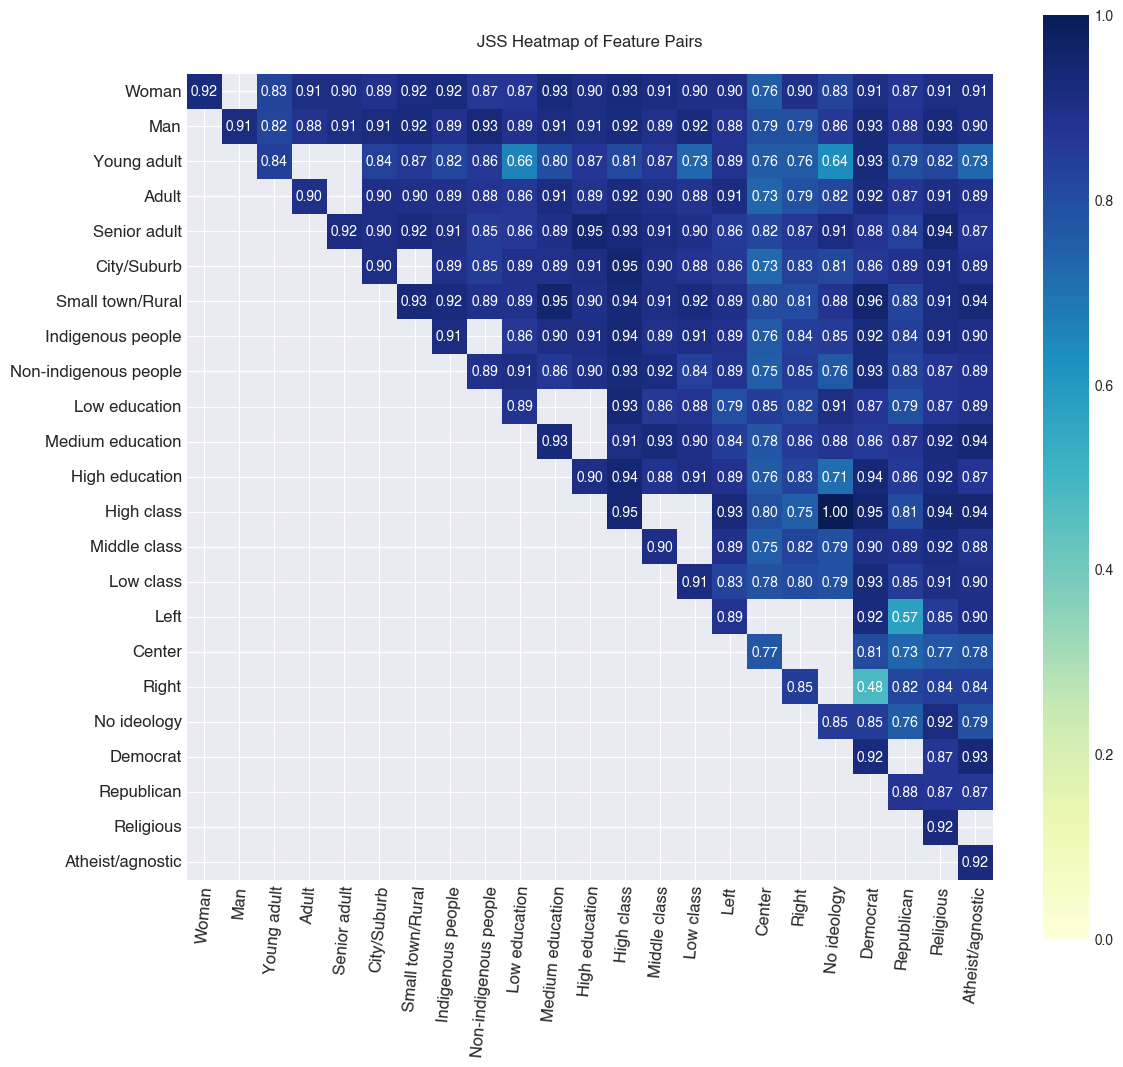

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
# Aplicar estilo
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

def plot_matrix(matrix, title):
  # Crea el gráfico
  plt.figure(figsize=(13, 12))

  # Nombres personalizados para las filas y columnas
  column_names = ["Woman", "Man", "Young adult", "Adult", "Senior adult", "City/Suburb", \
         "Small town/Rural", "Indigenous people", "Non-indigenous people", \
         "Low education", "Medium education", "High education", \
         "High class", "Middle class", "Low class", "Left", "Center", "Right", "No ideology", \
         "Democrat", "Republican", "Religious", "Atheist/agnostic"]

  #Crea el mapa
  ax = sns.heatmap(matrix, cmap='YlGnBu', annot=True, cbar=True, square=True,fmt='.2f', xticklabels=column_names, yticklabels=column_names, vmin=0, vmax=1)
  ax.set_xticklabels(column_names, fontsize=12, rotation=85)  # Cambia `fontsize` al tamaño deseado
  ax.set_yticklabels(column_names, fontsize=12)
  # Etiquetas y título
  plt.title('JSS Heatmap of Feature Pairs'+ title, pad=20)
  plt.show()
  
  
matrix = np.triu(matrix)
matrix[matrix == 0] = np.nan
plot_matrix(matrix, '')

### Plots

In [23]:
results_rf_1_eeuu = metrics_dataset_gen_anes(df_rf_1_eeuu, "elec_pres_144_a", 1, n_bootstrap=1000, random_seed=42)
results_rf_3_eeuu = metrics_dataset_gen_anes(df_rf_3_eeuu, "religion_14", 3, n_bootstrap=1000, random_seed=42)

results_llama_1_eeuu = metrics_dataset_gen_anes(llama_json_1_eeuu, "elec_pres_144_a", 1, n_bootstrap=1000, random_seed=42)
results_llama_3_eeuu = metrics_dataset_gen_anes(llama_json_3_eeuu, "religion_14", 3, n_bootstrap=1000, random_seed=42)

/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1382: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1382: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1381: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1382: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1382: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=T

In [ ]:
import scipy.stats as st

z = st.norm.ppf(0.975)  # ~1.96 for 95% CI
metric_cols = ["JSD", "Accuracy", "Media armónica", "JSS"]

# --- Llama aggregation across experiments ---
all_llama = [
    results_llama_1_eeuu[results_llama_1_eeuu['Group'] != 'Total'].reset_index(drop=True),
    results_llama_3_eeuu[results_llama_3_eeuu['Group'] != 'Total'].reset_index(drop=True),
]

agg_llama_eeuu = all_llama[0][["Group"]].copy()
for col in metric_cols:
    ci_lo_col = f"{col}_CI_lower"
    ci_hi_col = f"{col}_CI_upper"
    means = [m[col].astype(float) for m in all_llama]
    ses = [(m[ci_hi_col].astype(float) - m[ci_lo_col].astype(float)) / (2 * z) for m in all_llama]
    mean_vals = sum(means) / len(means)
    se_combined = np.sqrt(sum(se**2 for se in ses)) / len(ses)
    agg_llama_eeuu[col] = mean_vals
    agg_llama_eeuu[ci_lo_col] = mean_vals - z * se_combined
    agg_llama_eeuu[ci_hi_col] = mean_vals + z * se_combined

# --- Random Forest aggregation across experiments ---
all_rf = [
    results_rf_1_eeuu[results_rf_1_eeuu['Group'] != 'Total'].reset_index(drop=True),
    results_rf_3_eeuu[results_rf_3_eeuu['Group'] != 'Total'].reset_index(drop=True),
]

agg_rf_eeuu = all_rf[0][["Group"]].copy()
for col in metric_cols:
    ci_lo_col = f"{col}_CI_lower"
    ci_hi_col = f"{col}_CI_upper"
    means = [m[col].astype(float) for m in all_rf]
    ses = [(m[ci_hi_col].astype(float) - m[ci_lo_col].astype(float)) / (2 * z) for m in all_rf]
    mean_vals = sum(means) / len(means)
    se_combined = np.sqrt(sum(se**2 for se in ses)) / len(ses)
    agg_rf_eeuu[col] = mean_vals
    agg_rf_eeuu[ci_lo_col] = mean_vals - z * se_combined
    agg_rf_eeuu[ci_hi_col] = mean_vals + z * se_combined

print("=== Llama (USA aggregated) ===")
display(agg_llama_eeuu)
print("\n=== Random Forest (USA aggregated) ===")
display(agg_rf_eeuu)

=== Llama (USA aggregated) ===


,Group,JSD,JSD_CI_lower,JSD_CI_upper,Accuracy,Accuracy_CI_lower,Accuracy_CI_upper,Media armónica,Media armónica_CI_lower,Media armónica_CI_upper,JSS,JSS_CI_lower,JSS_CI_upper
0,Woman,0.042349,0.009513,0.075184,0.747509,0.716700,0.778319,0.819289,0.792762,0.845817,0.921888,0.889052,0.954724
1,Man,0.039797,0.005818,0.073776,0.737205,0.704641,0.769768,0.809145,0.780762,0.837529,0.913234,0.879255,0.947213
2,Young adult,0.009109,-0.081784,0.100002,0.780142,0.690526,0.869758,0.807888,0.725807,0.889969,0.840915,0.750021,0.931808
3,Adult,0.053160,0.021589,0.084731,0.711439,0.678870,0.744009,0.784749,0.756797,0.812701,0.898222,0.866651,0.929793
4,Senior adult,0.034868,-0.001508,0.071245,0.776711,0.743448,0.809973,0.835044,0.805651,0.864437,0.915827,0.879450,0.952204
5,City/Suburb,0.040876,0.008638,0.073114,0.715606,0.680333,0.750879,0.788432,0.758372,0.818492,0.903572,0.871333,0.935810
6,Small town/Rural,0.041271,0.009974,0.072567,0.761891,0.733750,0.790032,0.832861,0.808609,0.857113,0.929689,0.898393,0.960985
7,White,0.067795,0.042286,0.093304,0.746773,0.721188,0.772358,0.814625,0.792969,0.836281,0.910702,0.885193,0.936212
8,Non-White,0.024958,-0.025789,0.075704,0.729772,0.684286,0.775258,0.795171,0.755282,0.835060,0.894372,0.843625,0.945118
9,Low education,0.018525,-0.042415,0.079464,0.696262,0.638556,0.753968,0.767922,0.715459,0.820385,0.885736,0.824796,0.946676



=== Random Forest (USA aggregated) ===


,Group,JSD,JSD_CI_lower,JSD_CI_upper,Accuracy,Accuracy_CI_lower,Accuracy_CI_upper,Media armónica,Media armónica_CI_lower,Media armónica_CI_upper,JSS,JSS_CI_lower,JSS_CI_upper
0,Woman,0.023755,-0.019334,0.066845,0.690476,0.644345,0.736607,0.800890,0.762006,0.839774,0.953338,0.910248,0.996428
1,Man,0.017900,-0.025501,0.061301,0.689441,0.641266,0.737616,0.803685,0.762313,0.845057,0.963311,0.919910,1.006712
2,Young adult,0.008155,-0.142427,0.158737,0.727273,0.575758,0.878788,0.778242,0.640694,0.915791,0.836895,0.686313,0.987477
3,Adult,0.021487,-0.021469,0.064443,0.661017,0.610134,0.711900,0.782916,0.741532,0.824300,0.959939,0.916983,1.002896
4,Senior adult,0.011405,-0.025684,0.048494,0.721612,0.670330,0.772894,0.828452,0.790154,0.866750,0.972428,0.935338,1.009517
5,City/Suburb,0.013828,-0.027159,0.054815,0.667910,0.615672,0.720149,0.789746,0.749532,0.829959,0.965947,0.924960,1.006934
6,Small town/Rural,0.032031,-0.014628,0.078691,0.704082,0.659439,0.748724,0.807332,0.770839,0.843826,0.946070,0.899410,0.992730
7,White,0.002680,-0.019270,0.024629,0.697211,0.655378,0.739044,0.820405,0.789811,0.850998,0.996477,0.974527,1.018426
8,Non-White,0.043880,-0.035661,0.123421,0.664516,0.590323,0.738710,0.731360,0.666094,0.796626,0.813156,0.733615,0.892698
9,Low education,0.012162,-0.068522,0.092846,0.607477,0.509346,0.705607,0.733338,0.651096,0.815579,0.924982,0.844299,1.005666


In [25]:
# Compute ratio Llama / RF with Delta Method CIs
ratio_df_eeuu = agg_llama_eeuu[["Group"]].copy()

for metric in ["Accuracy", "JSS"]:
    ci_lo = f"{metric}_CI_lower"
    ci_hi = f"{metric}_CI_upper"

    x = agg_llama_eeuu[metric].astype(float)           # Llama
    y = agg_rf_eeuu[metric].astype(float)               # RF
    se_x = (agg_llama_eeuu[ci_hi].astype(float) - agg_llama_eeuu[ci_lo].astype(float)) / (2 * z)
    se_y = (agg_rf_eeuu[ci_hi].astype(float) - agg_rf_eeuu[ci_lo].astype(float)) / (2 * z)

    r = x / y
    se_r = r * np.sqrt((se_x / x)**2 + (se_y / y)**2)

    ratio_df_eeuu[metric] = r
    ratio_df_eeuu[f"{metric}_CI_lower"] = r - z * se_r
    ratio_df_eeuu[f"{metric}_CI_upper"] = r + z * se_r

ratio_df_eeuu

,Group,Accuracy,Accuracy_CI_lower,Accuracy_CI_upper,JSS,JSS_CI_lower,JSS_CI_upper
0,Woman,1.082600,0.997615,1.167585,0.967011,0.911363,1.022659
1,Man,1.069279,0.980885,1.157673,0.948016,0.892622,1.003410
2,Young adult,1.072695,0.817497,1.327893,1.004803,0.793896,1.215711
3,Adult,1.076280,0.979888,1.172673,0.935707,0.882463,0.988951
4,Senior adult,1.076355,0.987048,1.165663,0.941795,0.889932,0.993657
5,City/Suburb,1.071410,0.972360,1.170461,0.935426,0.883567,0.987285
6,Small town/Rural,1.082106,1.002702,1.161511,0.982686,0.924007,1.041365
7,White,1.071086,0.997082,1.145090,0.913923,0.881356,0.946489
8,Non-White,1.098200,0.957774,1.238627,1.099877,0.975499,1.224254
9,Low education,1.146154,0.938059,1.354249,0.957571,0.851189,1.063952


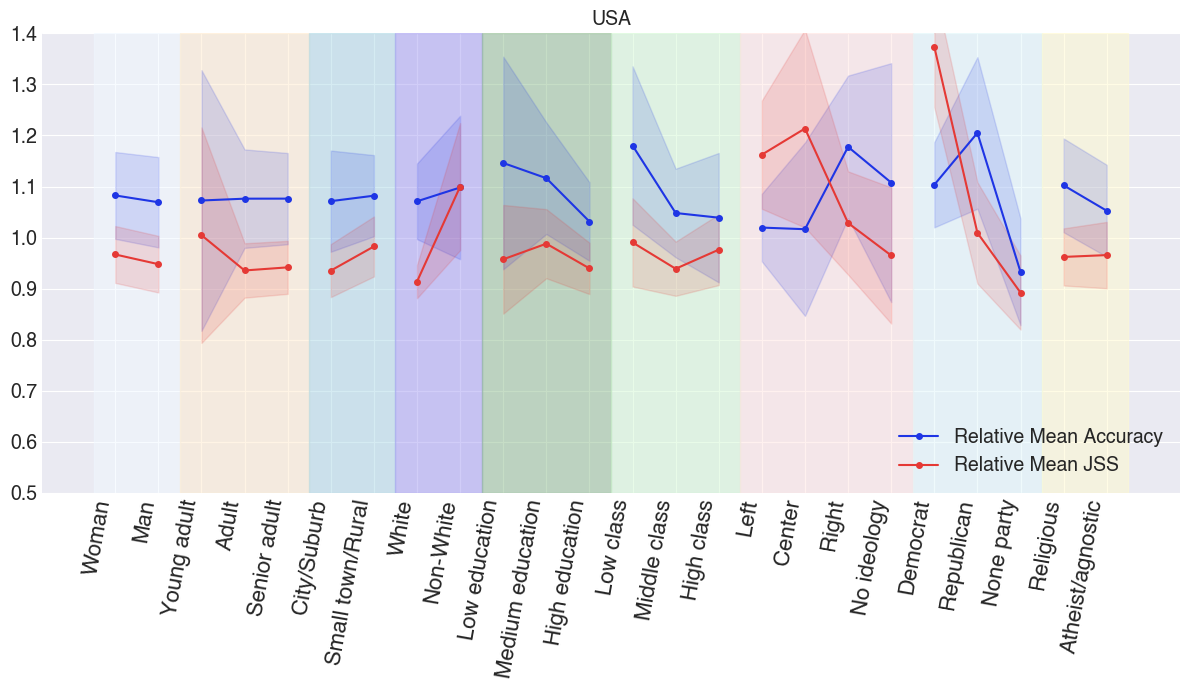

In [26]:
from matplotlib.transforms import ScaledTranslation

fig, ax = plt.subplots(figsize=(12, 7))
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

# Sociodemographic group ranges (after filtering "No religion response" and "Total")
grupos = {
    "Gender": (0, 1), "Age": (2, 4), "Region": (5, 6),
    "Race": (7, 8), "Education": (9, 11),
    "GSE": (12, 14), "Ideology": (15, 18),
    "Party": (19, 21), "Religion": (22, 23),
}
colores_bg = {
    "Gender": "#f0f8ff", "Age": "#ffebcd", "Region": "#add8e6",
    "Race": "#A49CF2", "Education": "#8FBC8F",
    "GSE": "#d3f8d3", "Ideology": "#ffe4e1",
    "Party": "#e0f7fa", "Religion": "#fffacd",
}
for grupo, (inicio, fin) in grupos.items():
    ax.axvspan(inicio - 0.5, fin + 0.5, color=colores_bg[grupo], alpha=0.5)

# Filter rows
data = ratio_df_eeuu[ratio_df_eeuu['Group'] != "No religion response"]
data = data[data['Group'] != "Total"]
data = data.reset_index(drop=True)

# Plot each metric
metric_colors = {"Accuracy": "#1e35e5", "JSS":  "#e53935"}
legend_names = {"Accuracy": "Relative Mean Accuracy", "JSS": "Relative Mean JSS"}
for metric, color in metric_colors.items():
    ci_lo = f"{metric}_CI_lower"
    ci_hi = f"{metric}_CI_upper"
    for grupo, (inicio, fin) in grupos.items():
        x = list(range(inicio, fin + 1))
        y = data[metric].iloc[inicio:fin + 1].astype(float)
        ax.plot(x, y, '-o', label=legend_names[metric] if grupo == "Gender" else "",
                color=color, markersize=4)
        y_lo = data[ci_lo].iloc[inicio:fin + 1].astype(float)
        y_hi = data[ci_hi].iloc[inicio:fin + 1].astype(float)
        ax.fill_between(x, y_lo, y_hi, color=color, alpha=0.15)

ax.set_ylim(bottom=0.5, top= 1.4)
ax.set_xticks(range(len(data["Group"])))
ax.set_xticklabels(data["Group"], rotation=80, ha='right', fontsize=16)
ax.legend(loc='lower right', fontsize=14)
# ax.set_ylabel("Ratio (Llama-13b / Random Forest)")
plt.yticks(fontsize=14)
ax.set_title("USA", fontsize=14)



plt.tight_layout()
fig.savefig("ratio_plot_usa.pdf", bbox_inches='tight')
plt.show()